In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns


# Load the data
data_delta = pd.read_csv('/Users/rb666/Projects/hypnomed/HYPNOMED2.0/Hypnomed_META/DATA/hypnomed_pheno/data_delta.csv')
data = data_delta


In [5]:
-data['meta_delta']

0    -10
1     -6
2      0
3      1
4      3
      ..
75     2
76     5
77     0
78    -4
79     2
Name: meta_delta, Length: 80, dtype: int64

In [6]:
# Calculate the combined_score : This calculation is based on the coefficients provided: Realness, absorption, and emotion have a coefficient of +1, and meta-awareness has a coefficient of -1.

data['combined_score'] = data['realness_delta'] + data['absorp_delta'] + data['emotion_delta'] - data['meta_delta']
data['negatif_meta_delta'] = - data['meta_delta']

# Display the first few rows of the data
data.head()



,Sujet,Bloc,age,genre,Version,state,difficulty_delta,emotion_delta,absorp_delta,meta_delta,realness_delta,combined_score,negatif_meta_delta
0,1,3,034Y,F,B,M,-3,2,0,10,-2,-10,-10
1,5,2,022Y,F,A,M,-9,0,0,6,-2,-8,-6
2,7,2,026Y,M,A,M,0,-2,2,0,-17,-17,0
3,14,3,022Y,F,B,M,0,3,-5,-1,-2,-3,1
4,21,3,063Y,M,B,M,4,1,2,-3,-7,-1,3


count    80.000000
mean      3.000000
std      19.518897
min     -37.000000
25%     -10.000000
50%       2.000000
75%      13.000000
max      58.000000
Name: combined_score, dtype: float64


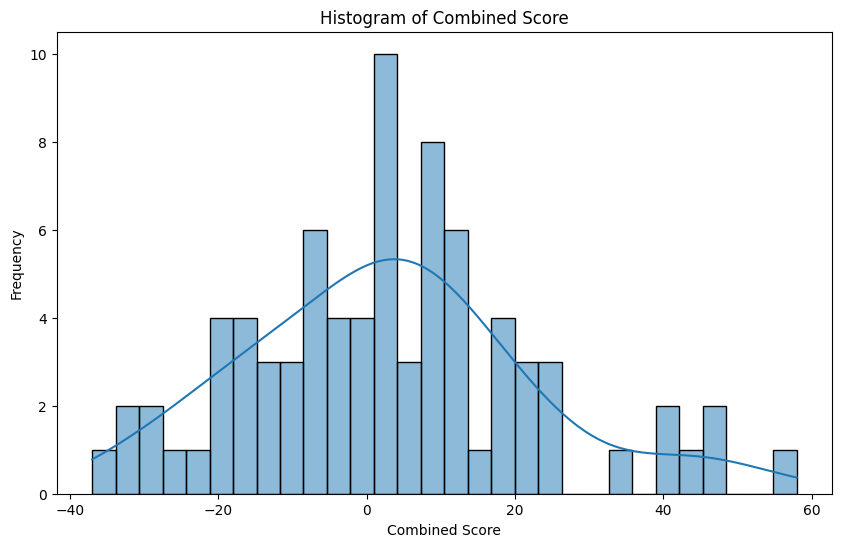

In [7]:
# Descriptive statistics of combined_score
print(data['combined_score'].describe())

# Histogram of combined_score
plt.figure(figsize=(10, 6))
sns.histplot(data['combined_score'], kde=True, bins=30)
plt.title('Histogram of Combined Score')
plt.xlabel('Combined Score')
plt.ylabel('Frequency')
plt.show()

### Calulate the correlation between the changes in each scale between the control state and the hypnotic state, and the control state and the meditation state

These correlation coefficients represent the strength and direction of the linear relationship between the two variables (hypnotic state and meditative states)

In [8]:
# Calculate the delta values for each scale at the hypnotic state
data_hypnotic = data[data['state'] == 'H']
data_meditation = data[data['state'] == 'M']

data_hypnotic = data_hypnotic.reset_index(drop=True)
data_meditation = data_meditation.reset_index(drop=True)




# Calculate correlation coefficient and p-value for 'realness_delta'
corr, p_value = pearsonr(data_hypnotic['realness_delta'], data_meditation['realness_delta'])
print(f"Realness Correlation: {corr}, P-value: {p_value}")

# Calculate correlation coefficient and p-value for 'absorp_delta'
corr, p_value = pearsonr(data_hypnotic['absorp_delta'], data_meditation['absorp_delta'])
print(f"Absorption Correlation: {corr}, P-value: {p_value}")

# Calculate correlation coefficient and p-value for 'emotion_delta'
corr, p_value = pearsonr(data_hypnotic['emotion_delta'], data_meditation['emotion_delta'])
print(f"Emotion Correlation: {corr}, P-value: {p_value}")

# Calculate correlation coefficient and p-value for 'meta_delta'
corr, p_value = pearsonr(data_hypnotic['meta_delta'], data_meditation['meta_delta'])
print(f"Meta Correlation: {corr}, P-value: {p_value}")


#Bonferroni correction

# Define the number of tests and the original significance level
num_tests = 4 #performing 4 correlation tests (one for each of 'realness_delta', 'absorp_delta', 'emotion_delta', and 'meta_delta')
alpha = 0.05

# Calculate the Bonferroni-corrected significance level
bonferroni_alpha = alpha / num_tests

# Print the corrected significance level
print(f"Bonferroni-corrected significance level: {bonferroni_alpha}")


Realness Correlation: 0.12155420334389608, P-value: 0.4549575667767747
Absorption Correlation: 0.28065750974519676, P-value: 0.07939680178717859
Emotion Correlation: 0.47004153259870735, P-value: 0.0022105938329262166
Meta Correlation: 0.5722373153500705, P-value: 0.00011435108742229957
Bonferroni-corrected significance level: 0.0125


In [9]:
data_hypnotic['combined_score_hypnotic'] = data_hypnotic['realness_delta'] + data_hypnotic['absorp_delta'] + data_hypnotic['emotion_delta'] - data_hypnotic['meta_delta']
data_meditation['combined_score_meditation'] = data_meditation['realness_delta'] + data_meditation['absorp_delta'] + data_meditation['emotion_delta'] - data_meditation['meta_delta']


# Calculate correlation coefficient and p-value for 'meta_delta'
corr, p_value = pearsonr(data_hypnotic['combined_score_hypnotic'], data_meditation['combined_score_meditation'])
print(f"Combined score Correlation: {corr}, P-value: {p_value}")

Combined score Correlation: -0.08095238402527355, P-value: 0.6194930046046899


In [10]:



# Calculate correlation coefficient and p-value for 'realness_delta'
corr, p_value = pearsonr(data['realness_delta'], data['absorp_delta'])
print(f"Realness / Absorb Correlation: {corr}, P-value: {p_value}")

# Calculate correlation coefficient and p-value for 'absorp_delta'
corr, p_value = pearsonr(data['realness_delta'], -data['meta_delta'])
print(f"Realness / Meta Correlation: {corr}, P-value: {p_value}")

# Calculate correlation coefficient and p-value for 'emotion_delta'
corr, p_value = pearsonr(data['realness_delta'], data['emotion_delta'])
print(f"Realness / Emotion  Correlation: {corr}, P-value: {p_value}")



#Bonferroni correction

# Define the number of tests and the original significance level
num_tests = 3 #performing 4 correlation tests (one for each of 'realness_delta', 'absorp_delta', 'emotion_delta', and 'meta_delta')
alpha = 0.05

# Calculate the Bonferroni-corrected significance level
bonferroni_alpha = alpha / num_tests


print(f"Bonferroni-corrected significance level: {bonferroni_alpha}")

Realness / Absorb Correlation: 0.7658013154157992, P-value: 1.291696511090818e-16
Realness / Meta Correlation: 0.008598274001424919, P-value: 0.9396607149369391
Realness / Emotion  Correlation: 0.4183448336225461, P-value: 0.00011265383695678866
Bonferroni-corrected significance level: 0.016666666666666666


In [11]:



# Calculate correlation coefficient and p-value for 'realness_delta'
corr, p_value = pearsonr(data_meditation['realness_delta'], data_meditation['absorp_delta'])
print(f"Realness / Absorb Correlation: {corr}, P-value: {p_value}")

# Calculate correlation coefficient and p-value for 'absorp_delta'
corr, p_value = pearsonr(data_meditation['realness_delta'], data_meditation['meta_delta'])
print(f"Realness / Meta Correlation: {corr}, P-value: {p_value}")

# Calculate correlation coefficient and p-value for 'emotion_delta'
corr, p_value = pearsonr(data_meditation['realness_delta'], data_meditation['emotion_delta'])
print(f"Realness / Emotion  Correlation: {corr}, P-value: {p_value}")



#Bonferroni correction

# Define the number of tests and the original significance level
num_tests = 3 #performing 4 correlation tests (one for each of 'realness_delta', 'absorp_delta', 'emotion_delta', and 'meta_delta')
alpha = 0.05

# Calculate the Bonferroni-corrected significance level
bonferroni_alpha = alpha / num_tests


print(f"Bonferroni-corrected significance level: {bonferroni_alpha}")

Realness / Absorb Correlation: 0.5325025820702062, P-value: 0.00040467933781519126
Realness / Meta Correlation: -0.3706003144302158, P-value: 0.01856906959243585
Realness / Emotion  Correlation: -0.06179546721902639, P-value: 0.7048378325372073
Bonferroni-corrected significance level: 0.016666666666666666


In [12]:



# Calculate correlation coefficient and p-value for 'realness_delta'
corr, p_value = pearsonr(data_hypnotic['realness_delta'], data_hypnotic['absorp_delta'])
print(f"Realness / Absorb Correlation: {corr}, P-value: {p_value}")

# Calculate correlation coefficient and p-value for 'absorp_delta'
corr, p_value = pearsonr(data_hypnotic['realness_delta'], data_hypnotic['meta_delta'])
print(f"Realness / Meta Correlation: {corr}, P-value: {p_value}")

# Calculate correlation coefficient and p-value for 'emotion_delta'
corr, p_value = pearsonr(data_hypnotic['realness_delta'], data_hypnotic['emotion_delta'])
print(f"Realness / Emotion  Correlation: {corr}, P-value: {p_value}")



#Bonferroni correction

# Define the number of tests and the original significance level
num_tests = 3 #performing 4 correlation tests (one for each of 'realness_delta', 'absorp_delta', 'emotion_delta', and 'meta_delta')
alpha = 0.05

# Calculate the Bonferroni-corrected significance level
bonferroni_alpha = alpha / num_tests


print(f"Bonferroni-corrected significance level: {bonferroni_alpha}")

Realness / Absorb Correlation: 0.8423085407803012, P-value: 9.541513336063756e-12
Realness / Meta Correlation: 0.3777486000505083, P-value: 0.01625559249522337
Realness / Emotion  Correlation: 0.48826647744752427, P-value: 0.0013917348358201973
Bonferroni-corrected significance level: 0.016666666666666666


Calculates the correlation coefficient and the p-value for each of the delta values between the hypnotic state and the meditation state. The correlation coefficient measures the strength and direction of the linear relationship between the two variables, while the p-value tests the null hypothesis that the correlation is zero. If the p-value is less than the chosen significance level (commonly 0.05), we reject the null hypothesis and conclude that there is a significant correlation between the two variables.

Realness Correlation (0.12): This suggests a weak positive linear relationship between the 'realness_delta' columns of the two dataframes. As the 'realness_delta' value increases in one dataframe, it also tends to slightly increase in the other dataframe.

Absorption Correlation (0.28): This suggests a weak to moderate positive linear relationship between the 'absorp_delta' columns of the two dataframes.

Emotion Correlation (0.47): This suggests a moderate positive linear relationship between the 'emotion_delta' columns of the two dataframes.

Meta Correlation (0.57): This suggests a moderate to strong positive linear relationship between the 'meta_delta' columns of the two dataframes.

We used the Bonferroni correctionto adjust the significance level as we made multiple comparisons, in order to control the family-wise error rate. 

In our case, the original significance level (alpha) is 0.05, and we performed 4 tests. Therefore, the Bonferroni-corrected significance level is 0.05 / 4 = 0.0125.

After we calculated the Bonferroni-corrected significance level, we compared the p-values of your tests with this new significance level. If a p-value is less than the Bonferroni-corrected significance level (0.0125 in this case), then we rejected the null hypothesis for that test, and conclude that there is a significant correlation between the two variables in that test.

This method helps to control the increased risk of Type I errors (false positives) when multiple comparisons are made. However, it is a conservative method and can increase the risk of Type II errors (false negatives). Therefore, the results should be interpreted with caution.